In [2]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models

In [3]:
#Configuration
sequence_length = 20
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']
target_features = ['delta_Lat', 'delta_Lng']

train_folder = 'data/train'
test_folder = 'data/test'

In [4]:
# Load and preprocess data from all CSV files in the 'train' folder
def load_data_from_folder(folder_path):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        # Load the CSV file and ignore the first row since its target is (0.0, 0.0)
        data = pd.read_csv(os.path.join(folder_path, file), delimiter=";")
        data = data.iloc[1:]
        
        # Add the data to sequences and targets (target features scaled *1000 for better training)
        sequences.append(data[input_features].values)
        targets.append(data[target_features].values * 1000)

    # Concatenate all sequences and targets
    sequences = np.vstack(sequences)
    targets = np.vstack(targets)

    return np.array(sequences), np.array(targets)

In [5]:
# Load training and test data
X_train, y_train = load_data_from_folder(train_folder)
X_test, y_test = load_data_from_folder(test_folder)

In [6]:
def create_model(input_dim):
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu', input_dim=input_dim))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(2))  # Output layer: 2 units (deltaLat, deltaLng) without activation (linear)
    
    # Compile the model with mean squared error loss (regression task)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

In [7]:
# Create model
model = create_model(input_dim=X_train.shape[1])

# Show model summary
model.summary()

c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,794 (69.51 KB)

 Trainable params: 17,794 (69.51 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# Train the model
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=200,  # Increase epochs for better training
                    batch_size=32,  # Experiment with different batch sizes
                    verbose=1)

# Save the trained model for future use
model.save('gps_position_predictor_model.keras')

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0233 - mae: 0.1128 - val_loss: 0.0051 - val_mae: 0.0575
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.0057 - mae: 0.0571 - val_loss: 0.0038 - val_mae: 0.0485
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - loss: 0.0055 - mae: 0.0534 - val_loss: 0.0028 - val_mae: 0.0421
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - loss: 0.0048 - mae: 0.0495 - val_loss: 0.0028 - val_mae: 0.0412
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.0043 - mae: 0.0479 - val_loss: 0.0033 - val_mae: 0.0444
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - loss: 0.0042 - mae: 0.0463 - val_loss: 0.0030 - val_mae: 0.0418
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - loss: 0.0044 - mae: 0.0471 - val_loss: 0.0028 - val_mae: 0.0422
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - loss: 0.0037 - mae: 0.0433 - val_loss: 0.0031 - val_mae: 0.0429
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/st

Validation Mean Absolute Error: 0.03167247772216797


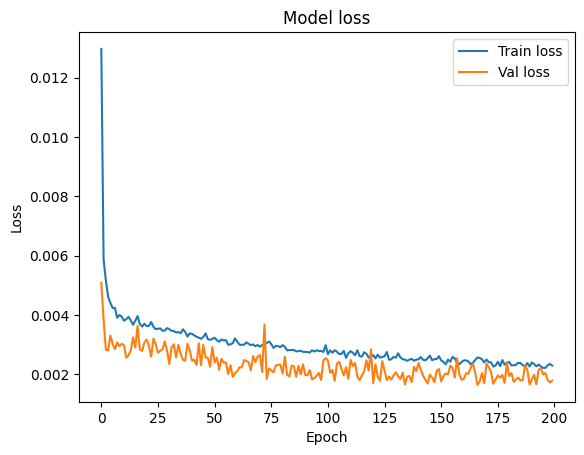

In [9]:
# Evaluate the model on the validation set
val_loss, val_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Validation Mean Absolute Error: {val_mae}")

# You can also plot the training loss and validation loss
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [11]:

import matplotlib.pyplot as plt
import numpy as np

def plot_real_and_predicted_routes(file_path, model):
    # Load the data
    data = pd.read_csv(file_path, delimiter=";")
    
    # Initialize the first point (real and predicted)
    real_points = []
    predicted_points = []
    
    # Get the first point (Lat, Lng)
    first_lat = data.iloc[0]['Lat']
    first_lng = data.iloc[0]['Lng']
    real_points.append([first_lng, first_lat])
    predicted_points.append([first_lng, first_lat])
    
    # Loop through the data from the second row onward
    for i in range(1, len(data)):
        # Real route: update position using delta_Lat and delta_Lng
        real_lng = real_points[-1][0] + data.iloc[i]['delta_Lng']
        real_lat = real_points[-1][1] + data.iloc[i]['delta_Lat']
        real_points.append([real_lng, real_lat])
        
        # Predicted route: make a prediction for delta_Lat and delta_Lng
        input_features = data.iloc[i][['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 
                                       'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 
                                       'Head', 'Temp', 'Press', 'delta_Alt']].values.reshape(1, -1)
        predicted_delta = model.predict(input_features)
        
        # Update predicted position using predicted delta_Lat and delta_Lng
        predicted_lng = predicted_points[-1][0] + predicted_delta[0][1] / 1000
        predicted_lat = predicted_points[-1][1] + predicted_delta[0][0] / 1000
        predicted_points.append([predicted_lng, predicted_lat])
    
    # Convert the lists to numpy arrays for easier plotting
    real_points = np.array(real_points)
    predicted_points = np.array(predicted_points)
    
    # Plot the real route (in blue) and the predicted route (in red)
    plt.figure(figsize=(10, 6))
    plt.plot(real_points[:, 0], real_points[:, 1], label='Real Route', color='blue', marker='o')
    plt.plot(predicted_points[:, 0], predicted_points[:, 1], label='Predicted Route', color='red', linestyle='--', marker='x')
    plt.title('Real vs Predicted Route')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9

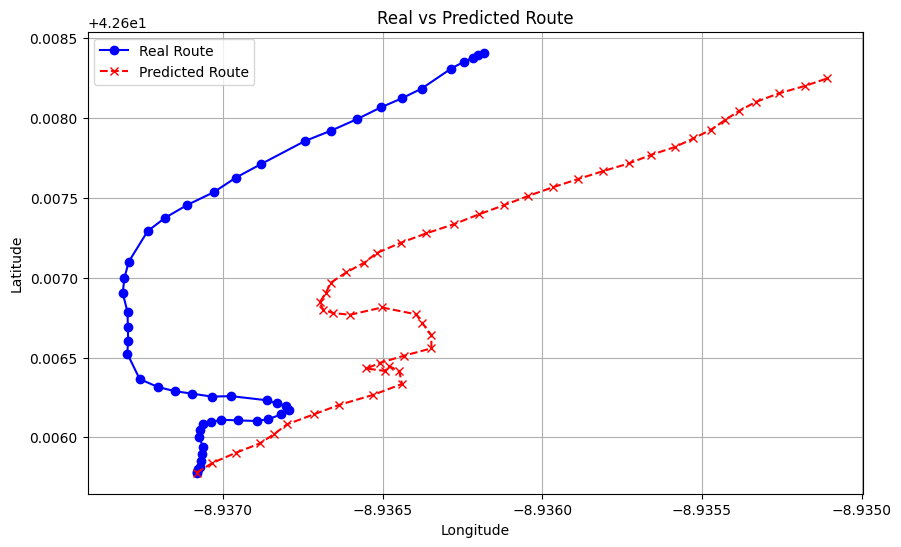

In [13]:
plot_real_and_predicted_routes('data/test/9_clean.csv', model)